# Figure 3 — Marmosets acquire a 2-armed bandit task
Source: `_source_archive/by_figure/Fig3/06_Fig3_2ABT_v2.ipynb`, LINES
1-1487 ONLY (everything past that belongs to Fig 4/6/7).
Panel legends below are copied verbatim from the submitted/bioRxiv
manuscript (`2026.06.30.734629v1.full.pdf`).

In [1]:
import os
import sys
import json

sys.path.insert(0, os.path.abspath(".."))

from IPython.display import SVG, display
import pandas as pd

from src.io.load_snapshots import load_config, load_snapshot
from src.features.history_encoding import add_history_cols_marmoset
from src.behavior_metrics.criterion import trials_to_criterion, clean_ttc, aggregate_to_session
from src.behavior_metrics.late_accuracy import late_accuracy
from src.behavior_metrics.wsls import win_stay_lose_shift_by_session, summarize_pooled
from src.behavior_metrics.switch_by_history import switch_probability_by_history
from src.behavior_metrics import reversal_alignment as revalign
from src.plotting.style import apply_style
from src.plotting import fig3 as plotting
from src.plotting import reversal_alignment as revalign_plotting

config = load_config()
apply_style(config)
cfg = config["fig3"]

FIG_DIR = os.path.join("..", config["paths"]["figures_out"], "Fig3")
os.makedirs(FIG_DIR, exist_ok=True)
MANIFEST_DIR = os.path.join("..", config["paths"]["values_manifests_out"])
os.makedirs(MANIFEST_DIR, exist_ok=True)

manifest = {}


def show(path):
    display(SVG(path))

## Load data

In [2]:
df = load_snapshot(config, cfg["input_files"]["reversal_80_20_2abt"])
df["High_Prob"] = df["ProbReward"].map({0.8: 1, 0.2: 0})

n_sessions_per_animal = df.groupby("Animal_Name")["Session_ID"].nunique()
n_trials_per_session = df.groupby("Session_ID").size()
print(f"Loaded {len(df):,} trials from {df['Session_ID'].nunique()} sessions, "
      f"{df['Animal_Name'].nunique()} animals")
manifest["n_trials"] = int(len(df))
manifest["n_sessions"] = int(df["Session_ID"].nunique())
manifest["n_animals"] = int(df["Animal_Name"].nunique())
manifest["sessions_per_animal_mean"] = float(n_sessions_per_animal.mean())
manifest["sessions_per_animal_sem"] = float(n_sessions_per_animal.sem())
manifest["trials_per_session_mean"] = float(n_trials_per_session.mean())
manifest["trials_per_session_sem"] = float(n_trials_per_session.sem())

Loaded 36,673 trials from 100 sessions, 5 animals


## Block transitions (no cued/uncued split -- 2-ABT has one transition type)
Used by panels a, b, c.

In [3]:
trans_records = []
for session_id, session_df in df.sort_values("Trial").groupby("Session_ID"):
    animal = session_df["Animal_Name"].iloc[0]
    block_counts = sorted(session_df["BlockCount"].unique())
    for i in range(1, len(block_counts)):
        trans_records.append({
            "session_id": session_id, "animal": animal,
            "to_block": block_counts[i],
        })
trans_df = pd.DataFrame(trans_records)
print(f"Total 2-ABT transitions: {len(trans_df)}")
manifest["n_transitions"] = int(len(trans_df))

Total 2-ABT transitions: 1779


## Panel a
**Manuscript legend:** *"Schematic representation of task structure and
example showing blocks, ITIs and performance across one session. In the
2-armed bandit task, the probability of reward for selecting one object
(high probability choice) is 0.8 and 0.2 for other object (low
probability choice). The identity and location of the rewarded visual
object are held constant for a variable length of trials (a block)
before reversing the reward contingencies for the two stimuli (uncued
reversal, vertical dashed line). Performance is given by the accuracy of
selecting the high probability choice over a 5-trial sliding window."*

The schematic illustration itself is not data-derived. The representative
session (data-derived half) is built here from the manuscript's own
exemplar-session code (`src/plotting/reversal_alignment.py::plot_exemplar_session`,
provided directly by the user, not reconstructed). Session picked as the
first session with >150 trials, matching that source code's own selection
rule. Note: the source code's choice-scatter/accuracy-trace both use the
raw `Outcome` (actual trial-level reward) column literally, even for this
probabilistic task -- NOT `High_Prob` (chose-the-high-probability-side),
which is what the rest of this figure's panels correctly use for
"accuracy" given 2-ABT's stochastic reward. Reproduced as given (this is
the manuscript's own code for this specific panel), flagged here rather
than silently "corrected" to High_Prob.

Panel a example session: 2022-04-25_20220425_Fiona_Reversal3.1 (497 trials)


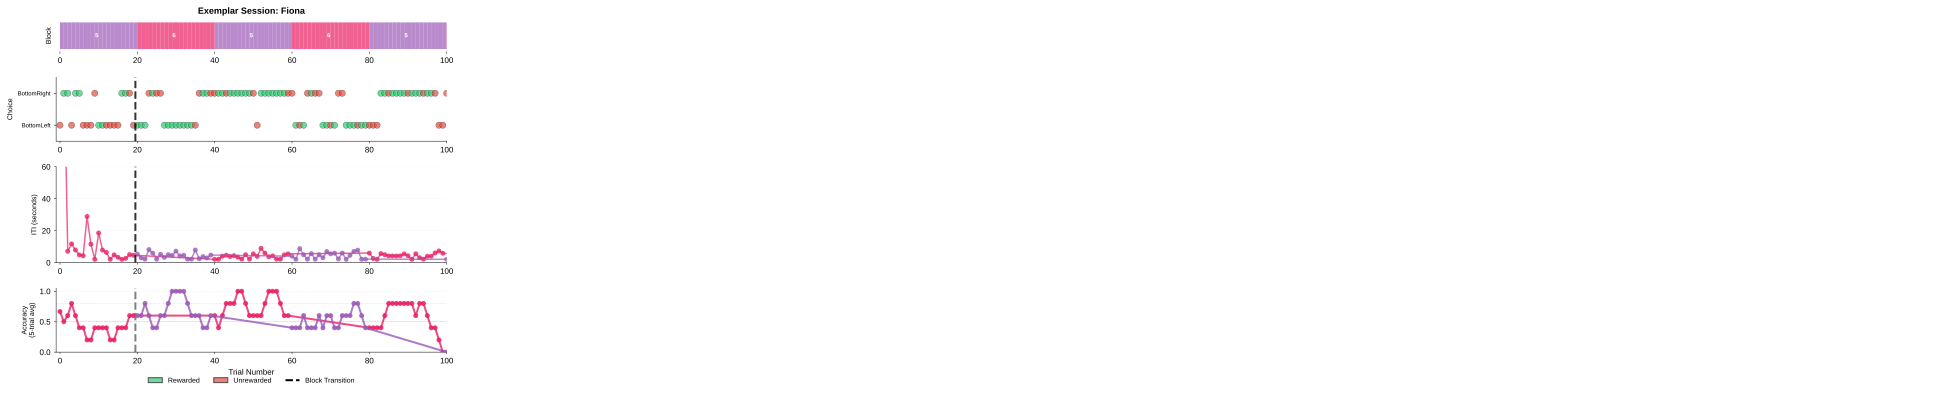

In [4]:
example_session_id = revalign.pick_representative_session(df)
session_data = df[df["Session_ID"] == example_session_id]
print(f"Panel a example session: {example_session_id} ({len(session_data)} trials)")
revalign_plotting.plot_exemplar_session(
    session_data, "Outcome", config, os.path.join(FIG_DIR, "representative_session.svg")
)
show(os.path.join(FIG_DIR, "representative_session.svg"))
manifest["representative_session_id"] = example_session_id

## Panel b
**Manuscript legend:** *"Probability of selecting the high probability
choice ('high-prob choice') at each trial position across an uncued
reversal where shaded error bars indicate standard error of mean."*

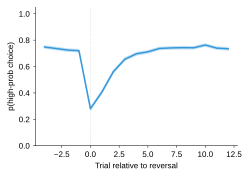

In [5]:
aligned_df = revalign.accuracy_by_position_relative_to_transition(
    df, trans_df, "High_Prob", cfg["reversal_window_before"], cfg["reversal_window_after"], block_col="BlockCount"
)
position_summary = revalign.summarize_by_position(aligned_df)
revalign_plotting.plot_reversal_alignment(
    position_summary, config, os.path.join(FIG_DIR, "reversal_alignment.svg"), split_by_type=False
)
show(os.path.join(FIG_DIR, "reversal_alignment.svg"))
manifest["reversal_alignment"] = {
    str(row["position"]): {"mean": float(row["mean"]), "sem": float(row["sem"]), "n": int(row["n"])}
    for _, row in position_summary.iterrows()
}

## Panel c
**Manuscript legend:** *"Trials to criterion (top, accuracy >= 0.8 across
5 trials) and the accuracy in the final 10 trials of a block (bottom,
'late accuracy') across all individual marmosets (bars) and sessions
(dots)."*

Blocks analyzed: 1764, reached criterion: 1653 (93.7%)


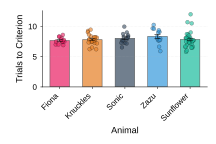

{'mean': np.float64(7.9031465924982305), 'sem': np.float64(0.10518619223452406), 'n': 99}


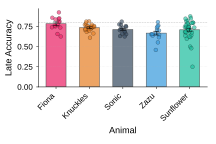

{'mean': np.float64(0.7193306625874369), 'sem': np.float64(0.009369330760995786), 'n': 100}


In [6]:
ttc_df = trials_to_criterion(
    df, trans_df, accuracy_col="High_Prob", block_col="BlockCount",
    criterion_accuracy=cfg["criterion_accuracy"], criterion_window=cfg["criterion_window"],
)
ttc_clean = clean_ttc(ttc_df)
pct_reached = len(ttc_clean) / len(ttc_df) * 100
print(f"Blocks analyzed: {len(ttc_df)}, reached criterion: {len(ttc_clean)} ({pct_reached:.1f}%)")

ttc_session = aggregate_to_session(ttc_clean, "trials_to_criterion")
ttc_stats = plotting.plot_trials_to_criterion(ttc_session, config, os.path.join(FIG_DIR, "trials_to_criterion.svg"))
show(os.path.join(FIG_DIR, "trials_to_criterion.svg"))
print(ttc_stats)
manifest["trials_to_criterion"] = {
    "n_blocks_total": int(len(ttc_df)), "n_reached_criterion": int(len(ttc_clean)),
    "pct_reached_criterion": float(pct_reached),
    "mean": float(ttc_stats["mean"]), "sem": float(ttc_stats["sem"]), "n": int(ttc_stats["n"]),
}

late_acc_df = late_accuracy(df, trans_df, accuracy_col="High_Prob", late_window=cfg["late_window"], block_col="BlockCount")
late_acc_session = aggregate_to_session(late_acc_df, "late_accuracy")
late_stats = plotting.plot_late_accuracy(late_acc_session, config, os.path.join(FIG_DIR, "late_accuracy.svg"))
show(os.path.join(FIG_DIR, "late_accuracy.svg"))
print(late_stats)
manifest["late_accuracy"] = {k: float(v) for k, v in late_stats.items()}

## Panel d
**Manuscript legend:** *"Probability of repeating after a reward
(win-stay) or switching after a loss (loss-switch) across all individual
marmosets (bars) and sessions (dots)."*

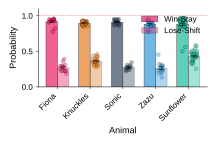

{'win_stay_mean': np.float64(0.893631663538249), 'win_stay_sem': np.float64(0.006535417007165205), 'lose_shift_mean': np.float64(0.34729769352380024), 'lose_shift_sem': np.float64(0.009504540807733296), 'n_sessions_win': 100, 'n_sessions_lose': 100}


In [7]:
wsls_sessions = win_stay_lose_shift_by_session(df)
pooled_wsls = summarize_pooled(wsls_sessions)
plotting.plot_wsls(wsls_sessions, pooled_wsls, config, os.path.join(FIG_DIR, "wsls.svg"))
show(os.path.join(FIG_DIR, "wsls.svg"))
print(pooled_wsls)
manifest["win_stay_lose_shift"] = {k: float(v) for k, v in pooled_wsls.items()}

## Panel e
**Manuscript legend:** *"Probability of switching based on the three
previous outcomes (rewarded = 1, unrewarded = 0) averaged across all
marmosets (black line) superimposed on top of individual marmoset
(colored lines)."*

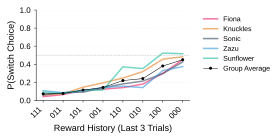

  reward_seq  p_switch       sem  n_animals  n_trials
7        111  0.072770  0.011828          5      9787
3        011  0.076961  0.003994          5      4679
5        101  0.114462  0.009135          5      3923
1        001  0.143038  0.013643          5      3455
6        110  0.219990  0.041907          5      4687
2        010  0.241540  0.040418          5      2696
4        100  0.380873  0.046009          5      3472
0        000  0.450241  0.024332          5      3674


In [8]:
df["test_choice"] = df["StimuliChosen"].map({"TargetA": 1, "TargetB": 0})
df["test_outcome"] = df["Reward"].map({"Rewarded": 1, "Unrewarded": 0})
df_hist = add_history_cols_marmoset(df, cfg["history_n"])
per_animal, overall = switch_probability_by_history(df_hist)
plotting.plot_switch_by_history(per_animal, overall, config, os.path.join(FIG_DIR, "switch_by_history.svg"))
show(os.path.join(FIG_DIR, "switch_by_history.svg"))
print(overall)
manifest["switch_by_history"] = overall.set_index("reward_seq")[["p_switch", "sem", "n_animals", "n_trials"]].to_dict(orient="index")

## Values manifest

In [9]:
manifest_path = os.path.join(MANIFEST_DIR, "Fig3.json")
with open(manifest_path, "w") as f:
    json.dump(manifest, f, indent=2, default=str)
print(f"\nSaved values manifest: {manifest_path}")


Saved values manifest: ../outputs/values_manifests/Fig3.json
